## Case Study: Previsão de Preços de Imóveis

Imagine que você trabalha em uma startup inovadora que está construindo um portal de imóveis para a região de King County, nos EUA. Seu objetivo é ajudar as pessoas a encontrar a casa dos seus sonhos e a entender o valor justo de mercado.

Você recebeu um conjunto de dados contendo informações sobre casas vendidas na região, com diversas características como número de quartos, banheiros, área construída, localização, etc., e o preço final de venda.

**Seu desafio é:**

Desenvolver um modelo de machine learning que seja capaz de prever o preço de uma casa com base nas suas características.

**Para isso, você deverá:**

1.  **Explorar os dados (EDA - Análise Exploratória de Dados):** Entenda o conjunto de dados, visualize a distribuição das variáveis, identifique possíveis correlações entre as características e o preço, e verifique a existência de valores ausentes ou outliers.
2.  **Preparar os dados:** Realize a engenharia de features (crie novas variáveis relevantes, se necessário), trate valores ausentes e aplique transformações nos dados (como normalização ou escalonamento) para preparar as features para o modelo.
3.  **Construir e treinar um modelo:** Comece com um modelo de regressão linear simples. Divida seus dados em conjuntos de treino e validação para avaliar o desempenho do modelo de forma justa.
4.  **Avaliar o modelo:** Utilize métricas apropriadas para regressão (como RMSE, MAE e R²) para entender o quão bem seu modelo está prevendo os preços.
5.  **Otimizar o modelo (Opcional, mas recomendado):** Experimente diferentes parametrizações para o seu modelo ou considere a criação de novas features para tentar melhorar suas métricas de avaliação.
6.  **Explicar suas descobertas:** Descreva as features que você considerou mais importantes, as transformações que aplicou e como elas impactaram o desempenho do modelo. O modelo atende às necessidades iniciais do problema?


In [ ]:
import matplotlib.pyplot as plt
import plotly.offline as py
import plotly.graph_objs as go
import seaborn as sns
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

np.random.seed(0)


warnings.filterwarnings('ignore')
py.init_notebook_mode(connected=True)
sns.set(style="white")
%matplotlib inline

##Conhecendo os dados

In [ ]:
# Raw Data
df  = pd.read_csv('https://raw.githubusercontent.com/jpvmm/Fasam_Analytics/master/train.csv', parse_dates=['date'], index_col=['id']).sort_values('date').reset_index()
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,5561000190,2014-05-02,437500.0,3,2.25,1970,35100,2.0,0,0,...,9,1970,0,1977,0,98027,47.4635,-121.991,2340,35100
1,2207200675,2014-05-02,419000.0,3,1.50,1570,6700,1.0,0,0,...,7,1570,0,1956,0,98007,47.6022,-122.134,1570,7300
2,3390600010,2014-05-02,365000.0,3,1.00,1090,6435,1.0,0,0,...,7,1090,0,1955,0,98106,47.5334,-122.365,1340,6435
3,7525000080,2014-05-02,588500.0,3,1.75,2330,14892,1.0,0,0,...,8,1970,360,1980,0,98074,47.6267,-122.046,2570,14217
4,5072200040,2014-05-02,403000.0,3,2.00,1960,13100,1.0,0,2,...,8,1650,310,1957,0,98166,47.4419,-122.340,1960,10518


In [ ]:
data_dictionary = {
    'id': 'ID único da casa',
    'date': 'Data de venda da casa',
    'price': 'Preço de venda da casa (Variável Alvo)',
    'bedrooms': 'Número de quartos',
    'bathrooms': 'Número de banheiros',
    'sqft_living': 'Área habitável em pés quadrados',
    'sqft_lot': 'Área do lote em pés quadrados',
    'floors': 'Número de andares',
    'waterfront': 'Indica se a casa tem vista para a água (0 ou 1)',
    'view': 'Um índice de 0 a 4 de quão boa é a vista da propriedade',
    'condition': 'Um índice de 1 a 5 da condição da casa',
    'grade': 'Um índice de 1 a 13, onde 1-3 é abaixo da construção e design do edifício, 7 é um nível médio de construção e design, e 11-13 é um alto nível de construção e design.',
    'sqft_above': 'Área em pés quadrados acima do nível do porão',
    'sqft_basement': 'Área em pés quadrados do porão',
    'yr_built': 'Ano em que a casa foi construída',
    'yr_renovated': 'Ano em que a casa foi renovada (0 se nunca foi renovada)',
    'zipcode': 'Código postal',
    'lat': 'Latitude',
    'long': 'Longitude',
    'sqft_living15': 'Área habitável média dos 15 vizinhos mais próximos',
    'sqft_lot15': 'Área média do lote dos 15 vizinhos mais próximos'
}

##Análise Exploratória

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19000 entries, 0 to 18999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             19000 non-null  int64         
 1   date           19000 non-null  datetime64[ns]
 2   price          19000 non-null  float64       
 3   bedrooms       19000 non-null  int64         
 4   bathrooms      19000 non-null  float64       
 5   sqft_living    19000 non-null  int64         
 6   sqft_lot       19000 non-null  int64         
 7   floors         19000 non-null  float64       
 8   waterfront     19000 non-null  int64         
 9   view           19000 non-null  int64         
 10  condition      19000 non-null  int64         
 11  grade          19000 non-null  int64         
 12  sqft_above     19000 non-null  int64         
 13  sqft_basement  19000 non-null  int64         
 14  yr_built       19000 non-null  int64         
 15  yr_renovated   1900

In [ ]:
df.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,1.900000e+04,19000,1.900000e+04,19000.000000,19000.000000,19000.000000,1.900000e+04,19000.000000,19000.000000,19000.000000,...,19000.000000,19000.000000,19000.000000,19000.000000,19000.000000,19000.000000,19000.00000,19000.000000,19000.000000,19000.000000
mean,4.565233e+09,2014-10-05 01:05:15.284210432,5.375214e+05,3.374842,2.118171,2084.267895,1.506762e+04,1.495947,0.007421,0.234842,...,7.662421,1791.511895,292.756000,1970.990684,86.446632,98077.824316,47.56047,-122.213884,1987.588842,12677.613579
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.15590,-122.519000,460.000000,651.000000
25%,2.112700e+09,2014-07-12 18:00:00,3.200000e+05,3.000000,1.750000,1430.000000,5.080000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.47160,-122.328000,1480.000000,5100.000000
50%,3.904901e+09,2014-09-24 00:00:00,4.500000e+05,3.000000,2.250000,1920.000000,7.642000e+03,1.500000,0.000000,0.000000,...,7.000000,1570.000000,0.000000,1975.000000,0.000000,98065.000000,47.57300,-122.231000,1840.000000,7629.500000
75%,7.300410e+09,2014-12-19 00:00:00,6.400000e+05,4.000000,2.500000,2550.000000,1.073125e+04,2.000000,0.000000,0.000000,...,8.000000,2220.000000,560.000000,1997.000000,0.000000,98117.000000,47.67840,-122.125000,2370.000000,10108.000000
max,9.900000e+09,2015-04-03 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.77760,-121.315000,6210.000000,871200.000000
std,2.877737e+09,NaN,3.652017e+05,0.933732,0.772107,921.265330,4.080810e+04,0.541342,0.085828,0.767797,...,1.177244,829.088291,444.785282,29.348882,406.288595,53.632028,0.13877,0.140870,685.111784,26557.077820


<Axes: ylabel='price'>

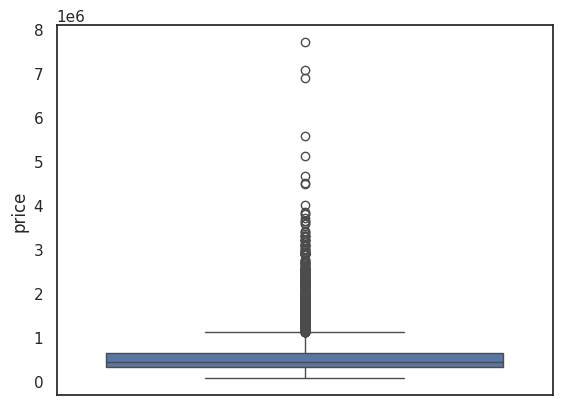

In [ ]:
#Conhecendo a distribuição da variável alvo (price)
sns.boxplot(y=df['price'])

In [ ]:
df.corr()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.003046,-0.017375,-0.000745,0.002560,-0.014428,-0.130222,0.013842,-0.003051,0.012403,...,0.006975,-0.012621,-0.006358,0.020312,-0.017868,-0.007762,-0.002728,0.020483,-0.003960,-0.135803
date,-0.003046,1.000000,-0.019804,-0.012749,-0.035523,-0.035225,0.006029,-0.022923,-0.000582,-0.000958,...,-0.042061,-0.028611,-0.019629,-0.001079,-0.021516,-0.002662,-0.036434,-0.008837,-0.037963,-0.004241
price,-0.017375,-0.019804,1.000000,0.307669,0.527495,0.705262,0.091877,0.260651,0.263240,0.403159,...,0.670632,0.609209,0.325203,0.053959,0.126287,-0.052602,0.308248,0.021967,0.585418,0.080964
bedrooms,-0.000745,-0.012749,0.307669,1.000000,0.513054,0.572883,0.032591,0.174403,-0.007128,0.078737,...,0.353244,0.474592,0.301940,0.149935,0.017595,-0.149413,-0.007511,0.126596,0.387999,0.028088
bathrooms,0.002560,-0.035523,0.527495,0.513054,1.000000,0.754026,0.085290,0.501801,0.059640,0.187359,...,0.664659,0.685806,0.283426,0.502634,0.048541,-0.199091,0.029937,0.219932,0.567596,0.079509
sqft_living,-0.014428,-0.035225,0.705262,0.572883,0.754026,1.000000,0.172732,0.354187,0.102747,0.288004,...,0.762794,0.876057,0.438271,0.313236,0.054708,-0.194245,0.056020,0.234930,0.753877,0.178329
sqft_lot,-0.130222,0.006029,0.091877,0.032591,0.085290,0.172732,1.000000,-0.004084,0.024438,0.079823,...,0.116424,0.181892,0.018724,0.053378,0.008730,-0.129318,-0.087455,0.226929,0.149604,0.719967
floors,0.013842,-0.022923,0.260651,0.174403,0.501801,0.354187,-0.004084,1.000000,0.022738,0.028756,...,0.459741,0.524303,-0.243698,0.488285,0.005492,-0.060605,0.051625,0.125131,0.280608,-0.013020
waterfront,-0.003051,-0.000582,0.263240,-0.007128,0.059640,0.102747,0.024438,0.022738,1.000000,0.394479,...,0.082097,0.072862,0.076999,-0.027325,0.092648,0.029624,-0.016639,-0.043844,0.088199,0.031746
view,0.012403,-0.000958,0.403159,0.078737,0.187359,0.288004,0.079823,0.028756,0.394479,1.000000,...,0.256292,0.168588,0.282278,-0.053364,0.102148,0.082283,0.007354,-0.078129,0.285764,0.072675


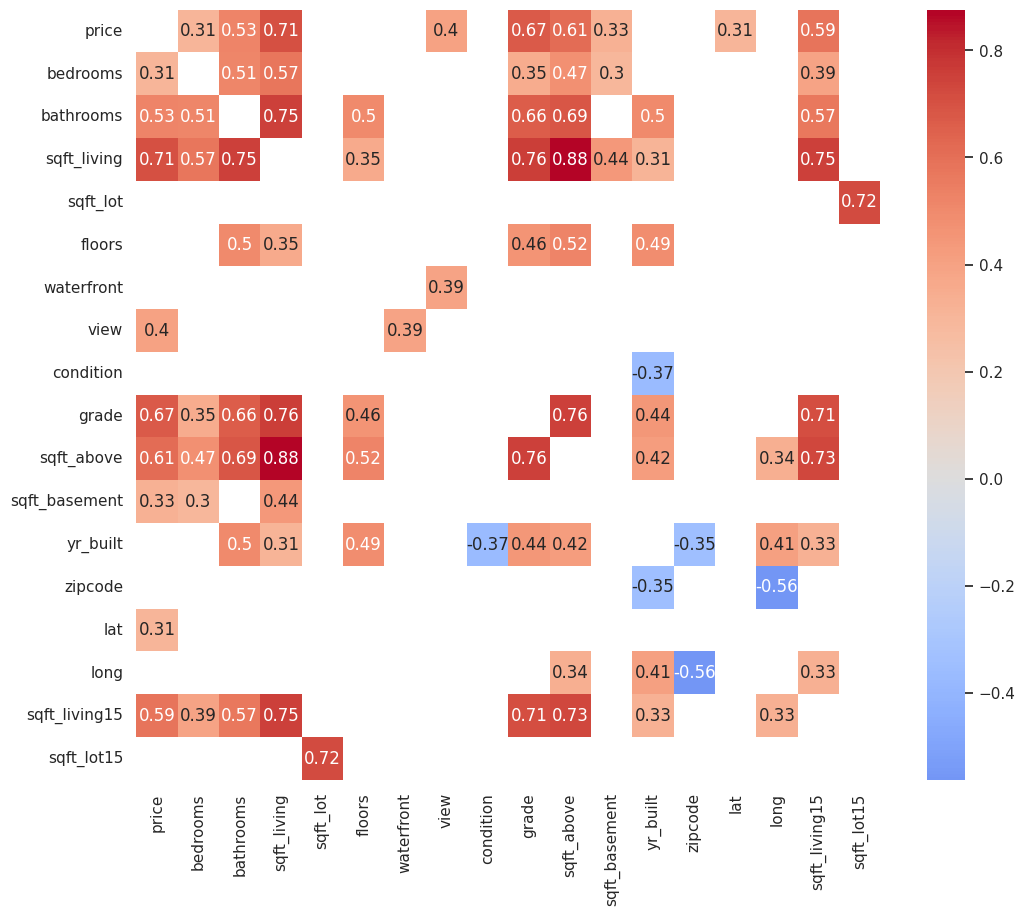

In [ ]:
#Visualizando a Correlação entre as variáveis
corr = df.corr()

# Aplica os filtros de limiar, excluindo a correlação perfeita e correlações fracas
filtro = (abs(corr) >= 0.3) & (corr != 1.0)
df_filtrado = corr.where(filtro).dropna(how = 'all').dropna(axis = 1, how = 'all')

plt.figure(figsize = (12, 10))
sns.heatmap(df_filtrado, annot = True, cmap = 'coolwarm', center = 0)
plt.show()

Podemos observar que existem 9 variáveis que possuem uma correlação moderada ou forte com a variável alvo (price), sendo elas: bedrooms, bathrooms, sqft_living, view, grade, sqft_above, sqft_basement, lat e sqft_living15.

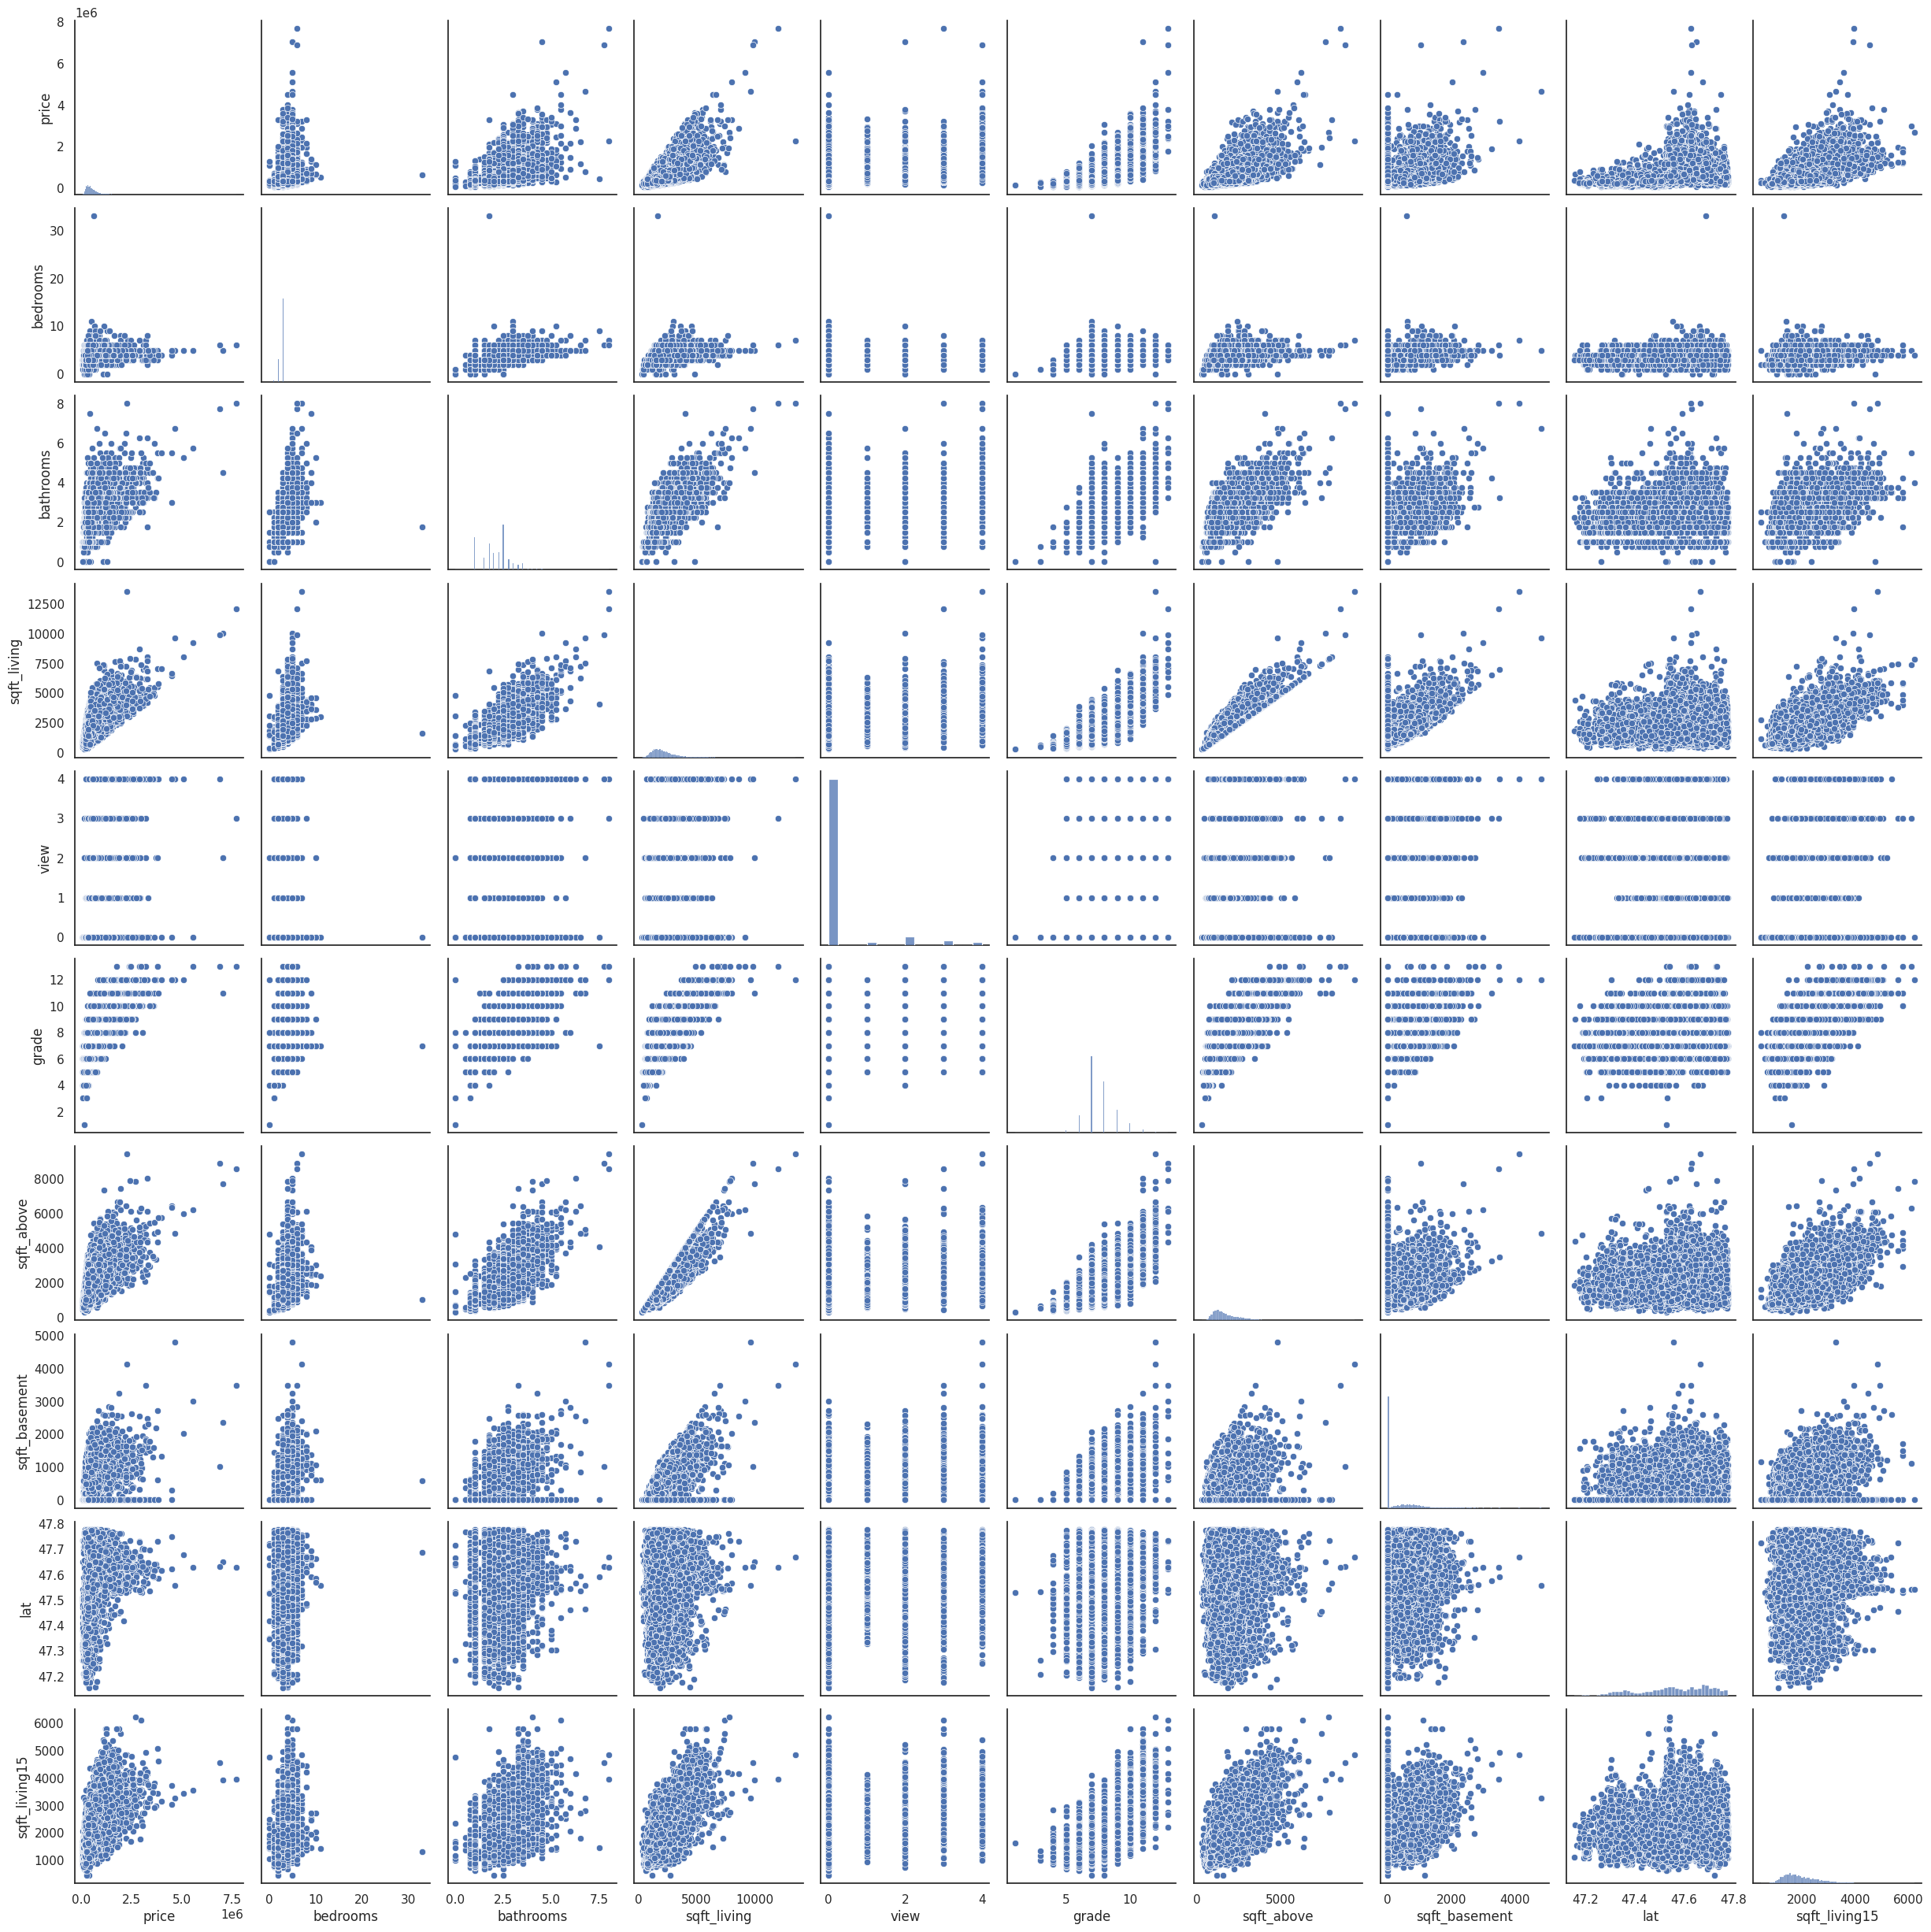

In [ ]:
features = ['price','bedrooms', 'bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']
sns.pairplot(df[features]);

##Modelagem Preditiva

In [ ]:
#Fazer uma cópia para facilitar análise
df_train = df

In [ ]:
df_train_1 = df_train.drop(['id', 'date'], axis=1)

In [ ]:
df_train_1.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,437500.0,3,2.25,1970,35100,2.0,0,0,4,9,1970,0,1977,0,98027,47.4635,-121.991,2340,35100
1,419000.0,3,1.50,1570,6700,1.0,0,0,4,7,1570,0,1956,0,98007,47.6022,-122.134,1570,7300
2,365000.0,3,1.00,1090,6435,1.0,0,0,4,7,1090,0,1955,0,98106,47.5334,-122.365,1340,6435
3,588500.0,3,1.75,2330,14892,1.0,0,0,3,8,1970,360,1980,0,98074,47.6267,-122.046,2570,14217
4,403000.0,3,2.00,1960,13100,1.0,0,2,5,8,1650,310,1957,0,98166,47.4419,-122.340,1960,10518


In [ ]:
# Avaliação
def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)
    return rmse, mae, r2

In [ ]:
# Features
X = df_train_1.drop(["price"], axis=1)

# Target
y = df_train_1['price']

In [ ]:
# Split
X_train, X_val, \
     y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_train)

StandardScaler()

In [ ]:
x_treino_scaled = scaler.transform(X_train)
x_val_scaled = scaler.transform(X_val)

In [ ]:
x_treino_scaled

array([[ 0.65738459,  0.16231627,  0.07133496, ..., -1.00563507,
        -0.16278197, -0.14897551],
       [-1.44684117, -0.47789631, -0.37622932, ...,  2.7403004 ,
        -0.62808185, -0.28020997],
       [ 0.65738459, -0.7980026 , -0.13113459, ..., -0.83536528,
        -0.13370073, -0.3113191 ],
       ...,
       [-1.44684117, -1.43821517, -0.72788697, ..., -0.87793273,
        -0.36635066, -0.32629757],
       [ 0.65738459,  0.48242256,  0.36971115, ...,  1.26462885,
         0.60787095, -0.31469886],
       [ 0.65738459,  0.16231627,  0.28446081, ...,  0.32105041,
         0.53516785, -0.19994072]])

###Versão 2 - Regressão Lasso

In [ ]:
modelo_v2 = Lasso(alpha = 1.0)

In [ ]:
modelo_v2.fit(x_treino_scaled, y_train)

Lasso()

In [ ]:
y_pred_v2 = modelo_v2.predict(x_val_scaled)

In [ ]:
(rmse, mae, r2) = eval_metrics(y_val, y_pred_v2)

print("RMSE: %s" % rmse)

print("MAE: %s" % mae)

print("R2: %s" % r2)

RMSE: 184794.0015905246
MAE: 123992.71254211885
R2: 0.6919468864553278


###Versão 3 - Random Forest

In [ ]:
modelo_v3 = RandomForestRegressor(n_estimators = 100, random_state = 42)
modelo_v3.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_v3 = modelo_v3.predict(X_val)

In [ ]:
(rmse, mae, r2) = eval_metrics(y_val, y_pred_v3)

print("RMSE: %s" % rmse)

print("MAE: %s" % mae)

print("R2: %s" % r2)

RMSE: 121303.23620234904
MAE: 66796.97316259968
R2: 0.8672621932058651


In [ ]:
# Identificando a importância das variáveis
importancias = modelo_v3.feature_importances_
variaveis = X.columns
importancias_df = pd.DataFrame({'Variável': variaveis, 'Importância': importancias}).sort_values(by = 'Importância', ascending = False)
importancias_df

,Variável,Importância
2,sqft_living,0.358000
8,grade,0.252597
14,lat,0.148841
15,long,0.064143
16,sqft_living15,0.028439
11,yr_built,0.024729
5,waterfront,0.023520
9,sqft_above,0.018808
6,view,0.017505
13,zipcode,0.014222


##Otimização do Modelo

Vamos partir do modelo de Random Forest para buscar um menor erro possível, já que essa família de modelo apresentou um erro menor comparado a família de regressão linear.

###Feature Engineering

In [ ]:
df_train_2 = df

In [ ]:
# Extraindo informações da data
df_train_2['sale_year'] = df_train_2['date'].dt.year
df_train_2['sale_month'] = df_train_2['date'].dt.month

# Diferença entre ano de venda e ano de construção/renovação
df_train_2['years_since_built'] = df_train_2['sale_year'] - df_train_2['yr_built']
df_train_2['years_since_renovated'] = df_train_2['sale_year'] - df_train_2['yr_renovated']
# Tratar casos onde yr_renovated é 0 (sem renovação)
df_train_2['years_since_renovated'] = df_train_2['years_since_renovated'].apply(lambda x: x if x > 0 else 0)

In [ ]:
#Construindo a variavel indice_vista
df_train_2['score_view'] = (df_train_2['view']) + (df_train_2['waterfront'] *5)

In [ ]:
#Construindo a variavel de percentual da area total utilizada
df_train_2['percent_built'] = (df_train_2['sqft_living'] / df_train_2['sqft_lot'])

In [ ]:
df_train_2['bath_per_bedroom'] = df_train_2['bathrooms'] / (df_train_2['bedrooms'] + 1)

In [ ]:
df_train_2['was_renovated'] = (df_train_2['yr_renovated'] > 0).astype(int)

In [ ]:
df_train_2.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_living15,sqft_lot15,sale_year,sale_month,years_since_built,years_since_renovated,score_view,percent_built,bath_per_bedroom,was_renovated
0,5561000190,2014-05-02,437500.0,3,2.25,1970,35100,2.0,0,0,...,2340,35100,2014,5,37,2014,0,0.056125,0.5625,0
1,2207200675,2014-05-02,419000.0,3,1.50,1570,6700,1.0,0,0,...,1570,7300,2014,5,58,2014,0,0.234328,0.3750,0
2,3390600010,2014-05-02,365000.0,3,1.00,1090,6435,1.0,0,0,...,1340,6435,2014,5,59,2014,0,0.169386,0.2500,0
3,7525000080,2014-05-02,588500.0,3,1.75,2330,14892,1.0,0,0,...,2570,14217,2014,5,34,2014,0,0.156460,0.4375,0
4,5072200040,2014-05-02,403000.0,3,2.00,1960,13100,1.0,0,2,...,1960,10518,2014,5,57,2014,2,0.149618,0.5000,0


In [ ]:
df_train_2 = df_train_2.drop(['id','date','sale_year','sale_month','view','waterfront','yr_built','yr_renovated','sqft_lot',
                              'bedrooms', 'bathrooms','yr_renovated'], axis=1)

In [ ]:
# Features
X_2 = df_train_2.drop(["price"], axis=1)

# Target
y_2 = df_train_2['price']

In [ ]:
# Split
X_train_2, X_val_2, \
     y_train_2, y_val_2 = train_test_split(X_2, y_2, test_size=0.33, random_state=42)

In [ ]:
modelo_v4 = RandomForestRegressor(n_estimators = 100, random_state = 42)
modelo_v4.fit(X_train_2, y_train_2)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_v4 = modelo_v4.predict(X_val_2)

In [ ]:
(rmse, mae, r2) = eval_metrics(y_val_2, y_pred_v4)

print("RMSE: %s" % rmse)

print("MAE: %s" % mae)

print("R2: %s" % r2)

RMSE: 120251.42504427524
MAE: 66664.95089063948
R2: 0.8695541322280903


In [ ]:
# Identificando a importância das variáveis
importancias = modelo_v4.feature_importances_
variaveis = X_2.columns
importancias_df = pd.DataFrame({'Variável': variaveis, 'Importância': importancias}).sort_values(by = 'Importância', ascending = False)
importancias_df

,Variável,Importância
0,sqft_living,0.358673
3,grade,0.252200
7,lat,0.149265
8,long,0.063904
13,score_view,0.041727
9,sqft_living15,0.028469
11,years_since_built,0.023945
4,sqft_above,0.019749
6,zipcode,0.014124
10,sqft_lot15,0.013122


###Salvando o melhor modelo

In [ ]:
from joblib import dump, load

In [ ]:
best_model = modelo_v4

# Save
dump(best_model, 'best_model.pkl')

['best_model.pkl']

###Avaliando o modelo com os dados de teste

In [ ]:
# Dados de teste
df_test  = pd.read_csv('https://raw.githubusercontent.com/jpvmm/Fasam_Analytics/master/valid.csv', parse_dates=['date'], index_col=['id']).sort_values('date').reset_index()
df_test.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,8682291390,2015-04-03,705000.0,2,2.50,2305,5580,1.0,0,0,...,8,2305,0,2007,0,98077,47.7203,-122.024,1440,5748
1,2493200155,2015-04-03,950000.0,4,2.25,2770,5320,2.0,0,1,...,9,2440,330,2013,0,98136,47.5283,-122.385,2100,6011
2,6445800120,2015-04-04,679000.0,4,1.75,2260,41236,1.0,0,0,...,8,1690,570,1962,0,98029,47.5528,-122.034,3080,30240
3,7237500110,2015-04-04,1208000.0,4,2.75,4250,10925,2.0,0,0,...,10,4250,0,2003,0,98059,47.5297,-122.140,4650,11544
4,5021900779,2015-04-04,785000.0,3,2.00,1600,9638,1.0,0,0,...,7,1600,0,1952,0,98040,47.5753,-122.224,1800,11400


In [ ]:
#Aplicando as transformações dos dados de treino nos dados de teste
df_test['sale_year'] = df_test['date'].dt.year
df_test['sale_month'] = df_test['date'].dt.month
df_test['years_since_built'] = df_test['sale_year'] - df_test['yr_built']
df_test['years_since_renovated'] = df_test['sale_year'] - df_test['yr_renovated']
df_test['years_since_renovated'] = df_test['years_since_renovated'].apply(lambda x: x if x > 0 else 0)
df_test['score_view'] = (df_test['view']) + (df_test['waterfront'] *5)
df_test['percent_built'] = (df_test['sqft_living'] / df_test['sqft_lot'])
df_test['bath_per_bedroom'] = df_test['bathrooms'] / (df_test['bedrooms'] + 1)
df_test['was_renovated'] = (df_test['yr_renovated'] > 0).astype(int)

df_test = df_test.drop(['id','date','sale_year','sale_month','view','waterfront','yr_built','yr_renovated','sqft_lot',
                              'bedrooms', 'bathrooms','yr_renovated'], axis=1)

In [ ]:
df_test.head()

,price,sqft_living,floors,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,years_since_built,years_since_renovated,score_view,percent_built,bath_per_bedroom,was_renovated
0,705000.0,2305,1.0,3,8,2305,0,98077,47.7203,-122.024,1440,5748,8,2015,0,0.413082,0.833333,0
1,950000.0,2770,2.0,3,9,2440,330,98136,47.5283,-122.385,2100,6011,2,2015,1,0.520677,0.450000,0
2,679000.0,2260,1.0,4,8,1690,570,98029,47.5528,-122.034,3080,30240,53,2015,0,0.054806,0.350000,0
3,1208000.0,4250,2.0,3,10,4250,0,98059,47.5297,-122.140,4650,11544,12,2015,0,0.389016,0.550000,0
4,785000.0,1600,1.0,5,7,1600,0,98040,47.5753,-122.224,1800,11400,63,2015,0,0.166010,0.500000,0


In [ ]:
model = load('best_model.pkl')
model

RandomForestRegressor(random_state=42)

In [ ]:
X_test = df_test.drop(["price"], axis=1)

# Target
y_test = df_test['price']
pred_y = model.predict(X_test)

# eval
(rmse, mae, r2) = eval_metrics(y_test, pred_y)

print("RMSE: %s" % rmse)
print("MAE: %s" % mae)
print("R2: %s" % r2)

RMSE: 144980.13182642366
MAE: 78053.59950535989
R2: 0.85451593209911


In [ ]:
tree_predictions = []
for tree in model.estimators_:
    tree_predictions.append(tree.predict(X_test))

predictions_array = np.array(tree_predictions)

lower_bound = np.percentile(predictions_array, 2.5, axis=0)
upper_bound = np.percentile(predictions_array, 97.5, axis=0)
mean_prediction = np.mean(predictions_array, axis=0)

print(f"Previsão Média: {mean_prediction[0]:,.2f}")
print(f"Intervalo de 95%: [ {lower_bound[0]:,.2f} , {upper_bound[0]:,.2f} ]")

Previsão Média: 653,421.05
Intervalo de 95%: [ 404,500.00 , 802,000.00 ]


##Utilizando o XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
df_train_2.head()

,price,sqft_living,floors,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,years_since_built,years_since_renovated,score_view,percent_built,bath_per_bedroom,was_renovated
0,437500.0,1970,2.0,4,9,1970,0,98027,47.4635,-121.991,2340,35100,37,2014,0,0.056125,0.5625,0
1,419000.0,1570,1.0,4,7,1570,0,98007,47.6022,-122.134,1570,7300,58,2014,0,0.234328,0.3750,0
2,365000.0,1090,1.0,4,7,1090,0,98106,47.5334,-122.365,1340,6435,59,2014,0,0.169386,0.2500,0
3,588500.0,2330,1.0,3,8,1970,360,98074,47.6267,-122.046,2570,14217,34,2014,0,0.156460,0.4375,0
4,403000.0,1960,1.0,5,8,1650,310,98166,47.4419,-122.340,1960,10518,57,2014,2,0.149618,0.5000,0


In [ ]:
# Remove outliers based on 3 standard deviations from the median
for col in df_train_2.columns:
	median = df_train_2[col].median()
	std_dev = df_train_2[col].std()
	threshold = 2 * std_dev
	df_train_3 = df_train_2[np.abs(df_train_2[col] - median) <= threshold]

df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18177 entries, 0 to 18999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price                  18177 non-null  float64
 1   sqft_living            18177 non-null  int64  
 2   floors                 18177 non-null  float64
 3   condition              18177 non-null  int64  
 4   grade                  18177 non-null  int64  
 5   sqft_above             18177 non-null  int64  
 6   sqft_basement          18177 non-null  int64  
 7   zipcode                18177 non-null  int64  
 8   lat                    18177 non-null  float64
 9   long                   18177 non-null  float64
 10  sqft_living15          18177 non-null  int64  
 11  sqft_lot15             18177 non-null  int64  
 12  years_since_built      18177 non-null  int64  
 13  years_since_renovated  18177 non-null  int64  
 14  score_view             18177 non-null  int64  
 15  percent

In [ ]:
# find columns with absolute correlation >= 0.25 with target 'price'
price_corr = df_train_3.corr()['price'].drop('price')
strong_corr = price_corr[price_corr.abs() >= 0.25].sort_values(ascending=False)

cols_strong = list(strong_corr.index)
df_train_3 = df_train_3[cols_strong + ['price']]
df_train_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18177 entries, 0 to 18999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sqft_living       18177 non-null  int64  
 1   grade             18177 non-null  int64  
 2   sqft_above        18177 non-null  int64  
 3   sqft_living15     18177 non-null  int64  
 4   score_view        18177 non-null  int64  
 5   bath_per_bedroom  18177 non-null  float64
 6   lat               18177 non-null  float64
 7   sqft_basement     18177 non-null  int64  
 8   floors            18177 non-null  float64
 9   price             18177 non-null  float64
dtypes: float64(4), int64(6)
memory usage: 1.5 MB


In [ ]:
# Features
X_3 = df_train_3.drop(["price"], axis=1)

# Target
y_3 = df_train_3['price']

In [ ]:
#Convertendo para um datatype especial do XGBoost
data_dmatrix = xgb.DMatrix(data=X_3,label=y_3)

In [ ]:
# Split
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(X_3, y_3, test_size=0.33, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {
     "eta": [0.05,0.06] ,
     "max_depth": [4,5],
     }

xgb_mdl = xgb.XGBRegressor()

grid = GridSearchCV(xgb_mdl, parameters, n_jobs=-1, cv = 2, scoring='neg_root_mean_squared_error')

In [ ]:
grid.fit(X_train_3, y_train_3)

GridSearchCV(cv=2,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1, param_grid={'eta': [0.05, 0.06], 'max_depth': [4, 5]},
             scoring='neg_root_mean_squared_error')

In [ ]:
grid.best_params_

{'eta': 0.06, 'max_depth': 5}

In [ ]:
preds = grid.predict(X_val_3)
rmse = np.sqrt(mean_squared_error(y_val_3, preds))
print("RMSE: %f" % (rmse))

RMSE: 147464.877790


In [ ]:
xgb_mdl = xgb.XGBRegressor()

In [ ]:
xgb_mdl.fit(X_train_2, y_train_2)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
preds_2 = xgb_mdl.predict(X_val_2)
rmse = np.sqrt(mean_squared_error(y_val_2, preds_2))
print("RMSE: %f" % (rmse))

RMSE: 118025.783925


In [ ]:
xgb_mdl.fit(X_train_3, y_train_3)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
preds_3 = xgb_mdl.predict(X_val_3)
rmse = np.sqrt(mean_squared_error(y_val_3, preds_3))
print("RMSE: %f" % (rmse))

RMSE: 149494.024085
